In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
fraud_df = pd.read_csv('../data/processed/cleaned_fraud_data.csv',parse_dates=["signup_time", "purchase_time"])
credit_df = pd.read_csv('../data/processed/cleaned_credit_data.csv')

In [3]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   user_id               151112 non-null  int64         
 1   signup_time           151112 non-null  datetime64[us]
 2   purchase_time         151112 non-null  datetime64[us]
 3   purchase_value        151112 non-null  int64         
 4   device_id             151112 non-null  str           
 5   source                151112 non-null  str           
 6   browser               151112 non-null  str           
 7   sex                   151112 non-null  str           
 8   age                   151112 non-null  int64         
 9   ip_address            151112 non-null  int64         
 10  class                 151112 non-null  int64         
 11  device_sharing_count  151112 non-null  int64         
 12  country               151112 non-null  str           
dtypes: datetim

## 1. Time Delta (Difference between signup and purchase time in hours)

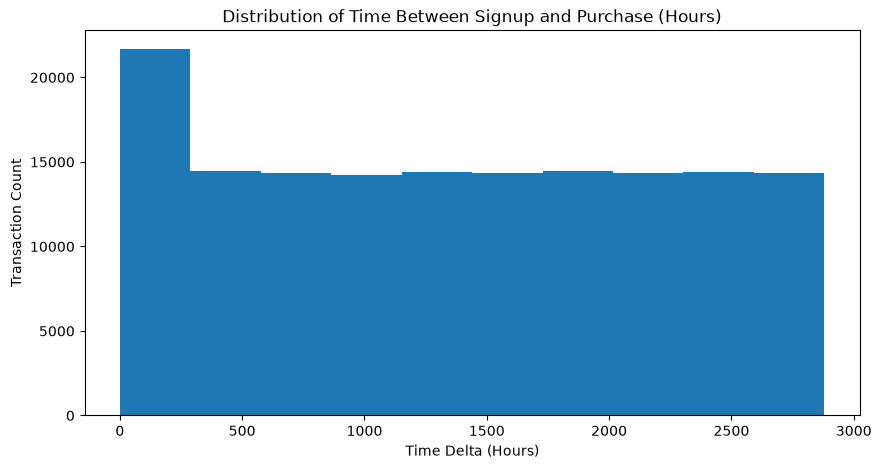

In [4]:
fraud_df['time_delta'] = (fraud_df['purchase_time'] - fraud_df['signup_time']).dt.total_seconds()/3600.0
plt.figure(figsize=(10, 5))
plt.hist(fraud_df['time_delta'])
plt.title('Distribution of Time Between Signup and Purchase (Hours)')
plt.xlabel('Time Delta (Hours)')
plt.ylabel('Transaction Count')
plt.show()

* There is a massive initial spike in transactions occurring immediately after account creation (0 to 200 hours). After that initial peak, transactions are evenly spread across time 

## 2. Transaction Frequency

In [15]:
fraud_df['purchase_hour'] = fraud_df['purchase_time'].dt.hour
fraud_df['purchase_day'] = fraud_df['purchase_time'].dt.dayofweek

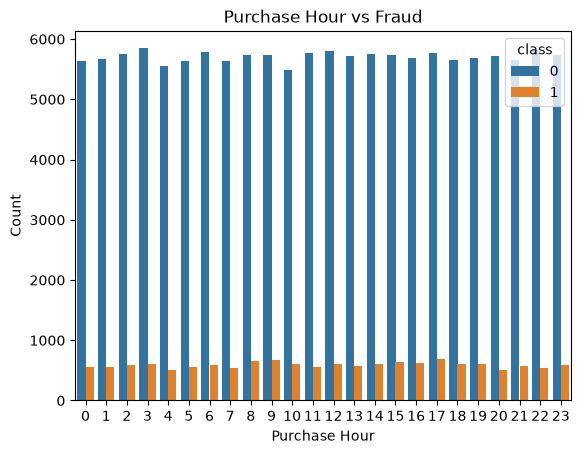

In [17]:
sns.countplot(x="purchase_hour", hue="class", data=fraud_df)
plt.title("Purchase Hour vs Fraud")
plt.xlabel("Purchase Hour")
plt.ylabel("Count")
plt.show()

* The proportion of fraudlent vs legitimate transactions across hours in a day is almost similar.

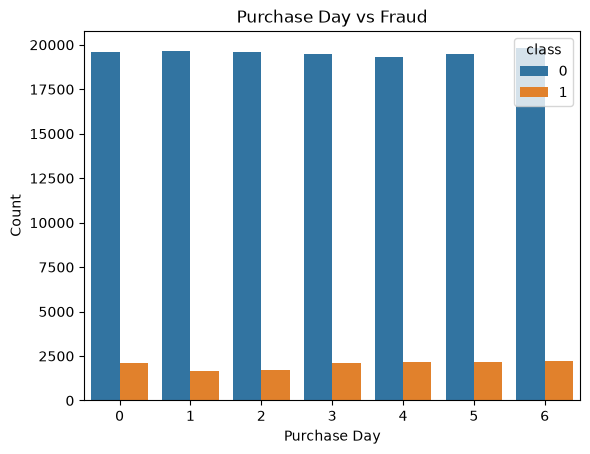

In [18]:
sns.countplot(x="purchase_day", hue="class", data=fraud_df)
plt.title("Purchase Day vs Fraud")
plt.xlabel("Purchase Day")
plt.ylabel("Count")
plt.show()

* The proportion of fraudlent vs legitimate transactions across days in a week is almost similar.

In [6]:
fraud_df = fraud_df.sort_values(['user_id', 'purchase_time'])
fraud_df_indexed = fraud_df.set_index('purchase_time')

fraud_df['tx_count_1h_user'] = (
    fraud_df_indexed.groupby('user_id')['user_id']
    .rolling('1h')
    .count()
    .reset_index(level=0, drop=True)
    .values
)

fraud_df['tx_count_24h_user'] = (
    fraud_df_indexed.groupby('user_id')['user_id']
    .rolling('24h')
    .count()
    .reset_index(level=0, drop=True)
    .values
)

fraud_df_device_indexed = fraud_df.sort_values(['device_id', 'purchase_time']).set_index('purchase_time')
fraud_df['tx_count_1h_device'] = (
    fraud_df_device_indexed.groupby('device_id')['device_id']
    .rolling('1h')
    .count()
    .reset_index(level=0, drop=True)
    .values
)

In [12]:
fraud_df[["user_id","purchase_time" ,"tx_count_1h_user","tx_count_24h_user","tx_count_1h_device","class"]].head(10)

,user_id,purchase_time,tx_count_1h_user,tx_count_24h_user,tx_count_1h_device,class
31545,2,2015-02-21 10:03:37,1.0,1.0,1.0,0
97542,4,2015-09-26 21:32:16,1.0,1.0,1.0,0
12873,8,2015-08-13 11:53:07,1.0,1.0,1.0,0
27671,9,2015-05-20 23:06:42,1.0,1.0,1.0,0
104500,12,2015-03-04 20:56:37,1.0,1.0,2.0,0
21011,16,2015-03-12 12:46:23,1.0,1.0,3.0,0
127701,18,2015-10-23 00:18:57,1.0,1.0,4.0,0
149684,26,2015-03-21 09:04:08,1.0,1.0,5.0,0
42090,33,2015-10-28 18:12:41,1.0,1.0,6.0,0
109634,39,2015-01-08 18:13:26,1.0,1.0,7.0,1


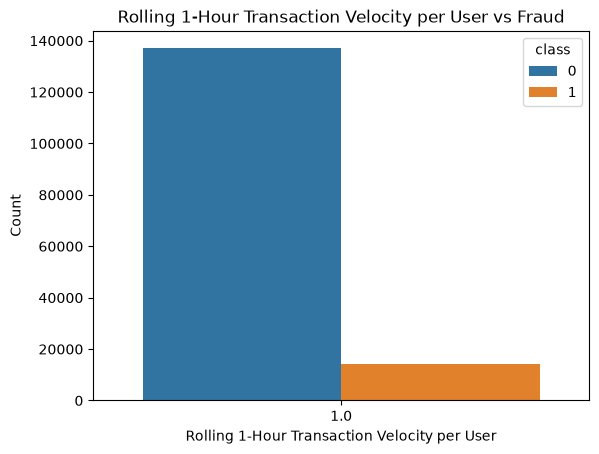

In [19]:
sns.countplot(x="tx_count_1h_user", hue="class", data=fraud_df)
plt.title("Rolling 1-Hour Transaction Velocity per User vs Fraud")
plt.xlabel("Rolling 1-Hour Transaction Velocity per User")
plt.ylabel("Count")
plt.show()

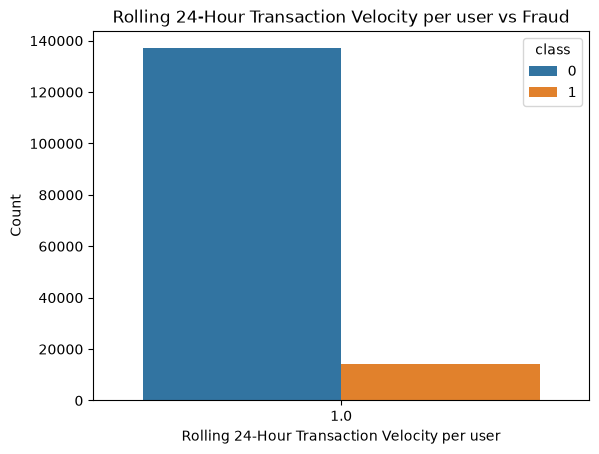

In [20]:
sns.countplot(x="tx_count_24h_user", hue="class", data=fraud_df)
plt.title("Rolling 24-Hour Transaction Velocity per user vs Fraud")
plt.xlabel("Rolling 24-Hour Transaction Velocity per user")
plt.ylabel("Count")
plt.show()

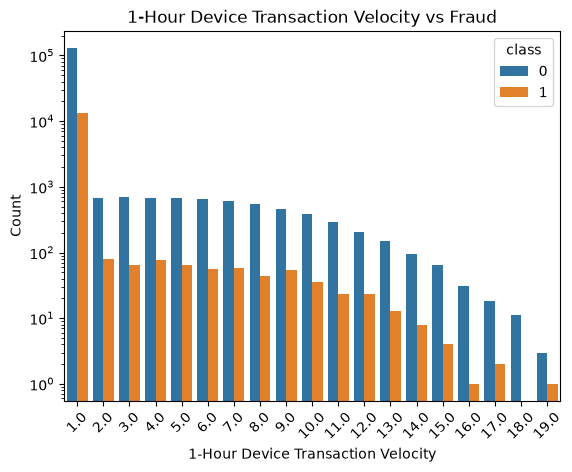

In [23]:
sns.countplot(x="tx_count_1h_device", hue="class", data=fraud_df)
plt.title("1-Hour Device Transaction Velocity vs Fraud")
plt.yscale('log')
plt.xlabel("1-Hour Device Transaction Velocity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

* Almost all transactions have a velocity of 1 purchase per hour. Higher speeds (2 to 19 purchases an hour on the same device) are much rarer.Even at super high speeds, fraud is always present alongside normal transactions

In [24]:
fraud_df.to_csv("../data/processed/cleaned_fraud_data.csv", index=False)

In [25]:
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,device_sharing_count,country,time_delta,purchase_hour,purchase_day,tx_count_1h_user,tx_count_24h_user,tx_count_1h_device
31545,2,2015-01-11 03:47:13,2015-02-21 10:03:37,54,FGBQNDNBETFJJ,SEO,Chrome,F,25,880217484,0,1,United States,990.273333,10,5,1.0,1.0,1.0
97542,4,2015-06-02 16:40:57,2015-09-26 21:32:16,41,MKFUIVOHLJBYN,Direct,Safari,F,38,2785906106,0,1,Switzerland,2788.855278,21,5,1.0,1.0,1.0
12873,8,2015-05-28 07:53:06,2015-08-13 11:53:07,47,SCQGQALXBUQZJ,SEO,Chrome,M,25,356056736,0,1,United States,1852.000278,11,3,1.0,1.0,1.0
27671,9,2015-05-16 15:58:32,2015-05-20 23:06:42,62,IEZOHXPZBIRTE,SEO,FireFox,M,21,759104706,0,1,Unknown,103.136111,23,2,1.0,1.0,1.0
104500,12,2015-01-10 06:25:12,2015-03-04 20:56:37,35,MSNWCFEHKTIOY,Ads,Safari,M,19,2985180352,0,1,Mexico,1286.523611,20,2,1.0,1.0,2.0
